<a href="https://colab.research.google.com/github/Despectinator/AIML-Internship-Muhammad-Ali/blob/main/Assignment1_EDA_MuhammadAli.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Weekend Assignment 01: Comprehensive EDA
## New York City Airbnb Open Data (2019)


## 1. Load & Inspect

Upload the dataset and load it with Pandas.

In [ ]:
from google.colab import files
uploaded = files.upload()   # select Assignment_Dataset_csv.csv

Saving Assignment_Dataset.csv.csv to Assignment_Dataset.csv (1).csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Assignment_Dataset.csv.csv")
df.head(10)

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,32785169,2 Bedroom Refuge with Private Bath & Living Room,20433973,Julia,Bronx,City Island,40.83988,-73.78287,Private room,95,1,6,2019-06-17,1.65,2,359
1,34399984,Two private rooms,259690766,Souadou,Bronx,Belmont,40.85648,-73.88501,Private room,95,2,4,2019-07-01,2.35,1,325
2,36379669,Shared living space in the Bronx!,44378432,Bryan,Bronx,Pelham Bay,40.84735,-73.83095,Shared room,50,1,0,NaN,NaN,1,88
3,35249458,Light-filled comfortable entire apartment,264809787,Kurt,Bronx,Concourse Village,40.82778,-73.91516,Entire home/apt,75,3,2,2019-06-21,2.00,1,253
4,30253236,SedaOn2 Dance Studio,140862407,Angelie,Bronx,Westchester Square,40.84378,-73.84469,Entire home/apt,670,1,2,2019-03-31,0.34,1,178
5,16506121,Beautifully private furnished room,108464471,Jeremiah,Bronx,Longwood,40.81790,-73.91456,Private room,100,6,0,NaN,NaN,1,365
6,19974905,Esteem's Place,141615596,Esteem,Bronx,Parkchester,40.83805,-73.85867,Shared room,26,1,18,2019-04-23,0.78,2,342
7,12345615,Natural light comfortable room!,52196858,Danny,Bronx,Parkchester,40.83648,-73.85812,Private room,59,1,120,2019-07-02,3.11,2,336
8,16476956,Newly renovated & Fully Furnished Super clean,51065605,Charles,Bronx,Port Morris,40.80743,-73.92971,Entire home/apt,115,5,7,2019-07-01,0.23,1,7
9,33363084,E community that is commercially (Website hidd...,242175033,Alex,Bronx,Allerton,40.86003,-73.86584,Entire home/apt,60,1,28,2019-07-02,8.32,1,74


Check the shape and column data types.

In [ ]:
print("Shape:", df.shape)
df.info()

Shape: (4889, 16)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4889 entries, 0 to 4888
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              4889 non-null   int64  
 1   name                            4886 non-null   object 
 2   host_id                         4889 non-null   int64  
 3   host_name                       4889 non-null   object 
 4   neighbourhood_group             4889 non-null   object 
 5   neighbourhood                   4889 non-null   object 
 6   latitude                        4889 non-null   float64
 7   longitude                       4889 non-null   float64
 8   room_type                       4889 non-null   object 
 9   price                           4889 non-null   int64  
 10  minimum_nights                  4889 non-null   int64  
 11  number_of_reviews               4889 non-null   int64  
 12  last_review     

**Identifying numeric vs. categorical columns:**

- **Numeric:** `id`, `host_id`, `latitude`, `longitude`, `price`, `minimum_nights`, `number_of_reviews`, `reviews_per_month`, `calculated_host_listings_count`, `availability_365`
- **Categorical / text:** `name`, `host_name`, `neighbourhood_group`, `neighbourhood`, `room_type`
- **Date (currently stored as text):** `last_review`

Note that `id` and `host_id` are numeric *in dtype only* — they are identifiers, not quantities, so they won't be used in any statistical or correlation analysis.

In [ ]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print("Numeric columns:", numeric_cols)
print("Categorical columns:", categorical_cols)

**Three initial observations (before any cleaning):**

1. `price` has an enormous range (the summary stats below show a minimum of \$0 and a maximum in the thousands), which already signals that the distribution is heavily right-skewed and will need a careful choice of chart/scale to visualize.
2. Two columns — `last_review` and `reviews_per_month` — have a large, *matching* number of missing values, which suggests these are simply listings that have never received a review, rather than random data-entry gaps.
3. `neighbourhood_group` is dominated by just two boroughs (Manhattan and Brooklyn), so any borough-level comparison should keep in mind that Staten Island and the Bronx have far fewer listings and their averages will be noisier.

In [ ]:
df.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889000e+03,4.889000e+03,4889.000000,4889.000000,4889.00000,4889.000000,4889.000000,3879.000000,4889.000000,4889.000000
mean,1.902666e+07,6.697190e+07,40.728549,-73.952288,155.46533,6.825731,23.643485,1.399588,6.830027,115.726529
std,1.091048e+07,7.795207e+07,0.054869,0.045684,286.86715,17.227167,43.762044,1.889328,31.722288,132.295573
min,5.803000e+03,2.787000e+03,40.522930,-74.212380,0.00000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,9.497513e+06,8.138665e+06,40.689760,-73.982950,70.00000,1.000000,1.000000,0.200000,1.000000,0.000000
50%,1.972056e+07,3.028359e+07,40.723060,-73.955720,106.00000,3.000000,5.000000,0.750000,1.000000,50.000000
75%,2.913442e+07,1.072729e+08,40.763060,-73.936710,179.00000,5.000000,24.000000,2.025000,2.000000,235.000000
max,3.648466e+07,2.743115e+08,40.903560,-73.726000,10000.00000,365.000000,447.000000,58.500000,327.000000,365.000000


## 2. Data Cleaning (With Justification)

### 2.1 Checking Missing Values

In [ ]:
df.isnull().sum()

,0
id,0
name,0
host_id,0
host_name,0
neighbourhood_group,0
neighbourhood,0
latitude,0
longitude,0
room_type,0
price,0


**Missing value strategy (two different strategies used, by column):**

- **`name` (3 missing):** Only a handful of rows are affected and the column is not used in any numeric or grouping analysis below, so I simply fill it with a placeholder `"Unknown"` rather than dropping rows and losing other useful data (price, location, etc.) from those listings.
- **`host_name` :** Same reasoning as `name` — filled with `"Unknown"` if missing, since it's an identifying text field, not something to compute statistics on.
- **`last_review` (1,010 missing) and `reviews_per_month` (1,010 missing, the same rows):** These are missing together because the listing simply has never been reviewed — this is *meaningful* missingness, not a data-entry error. Dropping ~20% of the dataset would throw away a lot of valid price/location data, so instead:
  - `reviews_per_month` is filled with `0` (no reviews per month makes sense for a listing with zero reviews).
  - `last_review` is left as `NaT` after date conversion (there is no sensible date to invent for a review that never happened), and I add a boolean helper column `has_reviews` to make this distinction easy to use in later analysis.

In [ ]:
df["name"] = df["name"].fillna("Unknown")
df["host_name"] = df["host_name"].fillna("Unknown")

df["has_reviews"] = df["reviews_per_month"].notnull()
df["reviews_per_month"] = df["reviews_per_month"].fillna(0)

df.isnull().sum()

,0
id,0
name,0
host_id,0
host_name,0
neighbourhood_group,0
neighbourhood,0
latitude,0
longitude,0
room_type,0
price,0


### 2.2 Fixing Data Types

In [ ]:
df["last_review"] = pd.to_datetime(df["last_review"], errors="coerce")
df["last_review"].head(10)

,last_review
0,2019-06-17
1,2019-07-01
2,NaT
3,2019-06-21
4,2019-03-31
5,NaT
6,2019-04-23
7,2019-07-02
8,2019-07-01
9,2019-07-02


### 2.3 Investigating Unrealistic Values in `price` and `minimum_nights`

In [ ]:
print("Listings with price == $0:", (df["price"] == 0).sum())
print("Listings with price >= $500:", (df["price"] >= 500).sum())
print("99th percentile price:", df["price"].quantile(0.99))
print()
print("Listings with minimum_nights > 30:", (df["minimum_nights"] > 30).sum())
print("Listings with minimum_nights >= 365:", (df["minimum_nights"] >= 365).sum())
print(df["minimum_nights"].sort_values(ascending=False).head(10))

Listings with price == $0: 4
Listings with price >= $500: 125
99th percentile price: 800.0

Listings with minimum_nights > 30: 65
Listings with minimum_nights >= 365: 5
850     365
3827    365
3908    365
2341    365
4881    365
3510    270
1441    265
3317    240
2810    185
2703    180
Name: minimum_nights, dtype: int64


**Decision & justification:**

- **Price = \$0:** A real listing cannot rent for \$0 a night — this is almost certainly a data-entry error or a placeholder. Only 4 rows are affected, so I drop them rather than trying to impute a price.
- **Extremely high prices:** Genuine luxury listings can legitimately cost several hundred dollars a night, so I don't want to blanket-delete high prices. Instead I cap analysis awareness at the 99th percentile (\$800) — rows above this are kept in the cleaned dataset (they're real, just rare) but I will use a **capped/log view specifically for plotting** so extreme values don't crush the rest of the distribution.
- **`minimum_nights`:** A minimum stay of 365+ nights is not a realistic short-term rental requirement — these look like hosts effectively blocking the listing rather than genuine short-term-rental terms. I cap `minimum_nights` at 30 (a generous upper bound for a legitimate short/medium-term stay) — 65 rows exceed this and are set to the 30-night cap rather than dropped, so we don't lose their price/location information.

In [ ]:
df_clean = df[df["price"] > 0].copy()

df_clean.loc[df_clean["minimum_nights"] > 30, "minimum_nights"] = 30

print("Rows before cleaning:", df.shape[0])
print("Rows after cleaning:", df_clean.shape[0])

Rows before cleaning: 4889
Rows after cleaning: 4885


### 2.4 Engineered Column: `price_category`

**Logic:** I bucket each listing into `Budget`, `Mid-range`, or `Luxury` based on its price, using the 33rd and 80th percentiles of the cleaned price column as cutoffs (rather than arbitrary round numbers), so the categories reflect the actual shape of this dataset's price distribution instead of an assumption borrowed from a different city or market.

In [ ]:
low_cut = df_clean["price"].quantile(0.33)
high_cut = df_clean["price"].quantile(0.80)

def price_category(price):
    if price <= low_cut:
        return "Budget"
    elif price <= high_cut:
        return "Mid-range"
    else:
        return "Luxury"

df_clean["price_category"] = df_clean["price"].apply(price_category)

print(f"Budget: <= ${low_cut:.0f} | Mid-range: ${low_cut:.0f}-${high_cut:.0f} | Luxury: > ${high_cut:.0f}")
df_clean["price_category"].value_counts()

Budget: <= $80 | Mid-range: $80-$200 | Luxury: > $200


,count
price_category,
Mid-range,2371
Budget,1676
Luxury,838


## 3. Univariate Analysis

### 3.1 Distribution of `price`

`price` is heavily right-skewed (a small number of very expensive listings stretch the axis and hide the shape of the bulk of the data). A plain histogram over the full range would be unreadable, so I use two complementary views: a histogram limited to listings under \$500 (covering the large majority of the data) and a log-scaled histogram capturing the full range.

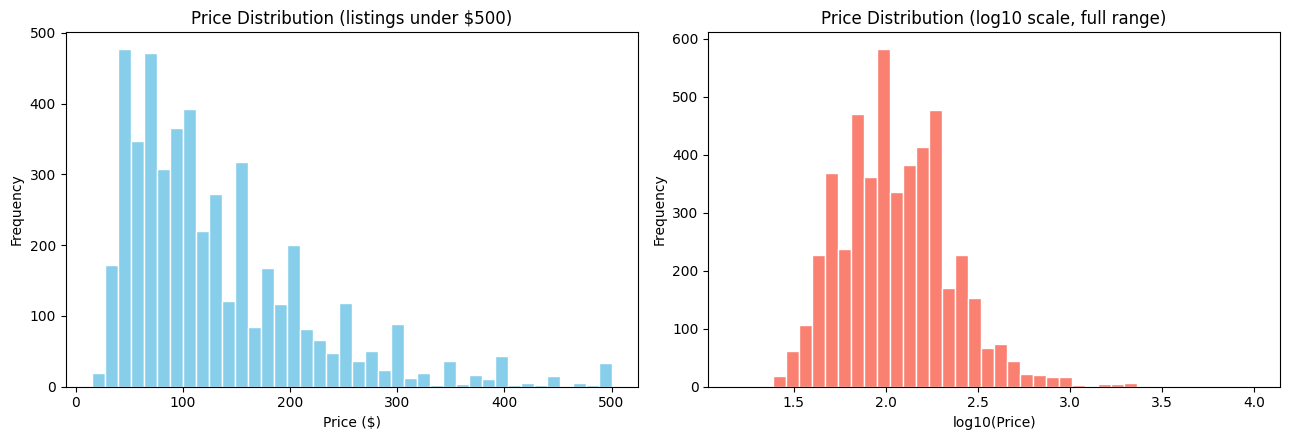

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].hist(df_clean[df_clean["price"] <= 500]["price"], bins=40, color="skyblue", edgecolor="white")
axes[0].set_title("Price Distribution (listings under $500)")
axes[0].set_xlabel("Price ($)")
axes[0].set_ylabel("Frequency")

axes[1].hist(np.log10(df_clean["price"]), bins=40, color="salmon", edgecolor="white")
axes[1].set_title("Price Distribution (log10 scale, full range)")
axes[1].set_xlabel("log10(Price)")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

**Interpretation:** Most listings cluster between roughly \$50-\$150 a night, with a sharp peak around \$70-\$100. The log-scale view on the right confirms the distribution is approximately log-normal — common for pricing data — and shows a long thin tail of expensive outlier listings that would otherwise be invisible on a linear-scale histogram.

### 3.2 Distribution of `room_type`

/tmp/ipykernel_9044/711794870.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="room_type", data=df_clean, order=df_clean["room_type"].value_counts().index, palette="Blues_d")


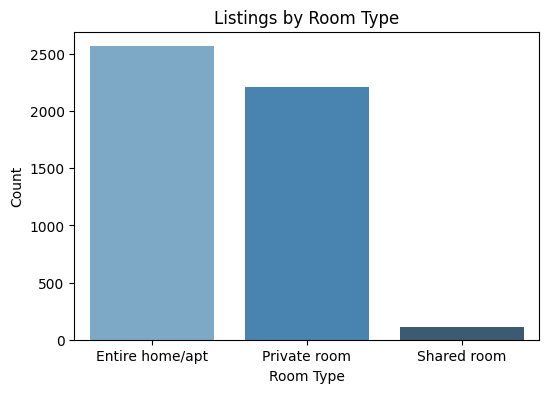

In [ ]:
plt.figure(figsize=(6, 4))
sns.countplot(x="room_type", data=df_clean, order=df_clean["room_type"].value_counts().index, palette="Blues_d")
plt.title("Listings by Room Type")
plt.xlabel("Room Type")
plt.ylabel("Count")
plt.show()

**Interpretation:** `Entire home/apt` and `Private room` make up almost all listings in roughly similar numbers, while `Shared room` is a small minority. This suggests the NYC market is split fairly evenly between hosts renting a whole space versus a room within their home, with almost no demand or supply for shared rooms.

### 3.3 Distribution of `neighbourhood_group`

/tmp/ipykernel_9044/4087942681.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="neighbourhood_group", data=df_clean,


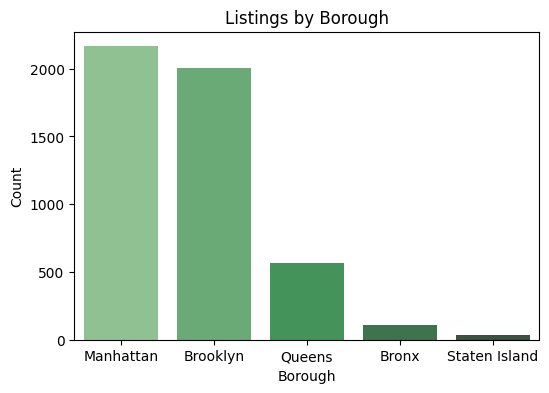

In [ ]:
plt.figure(figsize=(6, 4))
sns.countplot(x="neighbourhood_group", data=df_clean,
              order=df_clean["neighbourhood_group"].value_counts().index, palette="Greens_d")
plt.title("Listings by Borough")
plt.xlabel("Borough")
plt.ylabel("Count")
plt.show()

**Interpretation:** Manhattan and Brooklyn together account for the vast majority of listings, while Staten Island and the Bronx have very few. Any statistic computed per-borough (like an average price) will be far more reliable for Manhattan/Brooklyn than for Staten Island, which has only a few dozen listings.

### 3.4 Distribution of `minimum_nights` (cleaned)

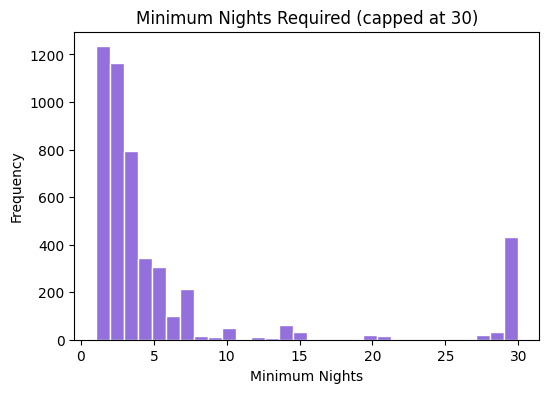

In [ ]:
plt.figure(figsize=(6, 4))
plt.hist(df_clean["minimum_nights"], bins=30, color="mediumpurple", edgecolor="white")
plt.title("Minimum Nights Required (capped at 30)")
plt.xlabel("Minimum Nights")
plt.ylabel("Frequency")
plt.show()

**Interpretation:** After capping, the overwhelming majority of listings require just 1-3 nights minimum stay, confirming this is primarily a short-term/tourist rental market rather than one geared toward extended stays.

## 4. Bivariate & Multivariate Analysis

### 4.1 Price by Borough

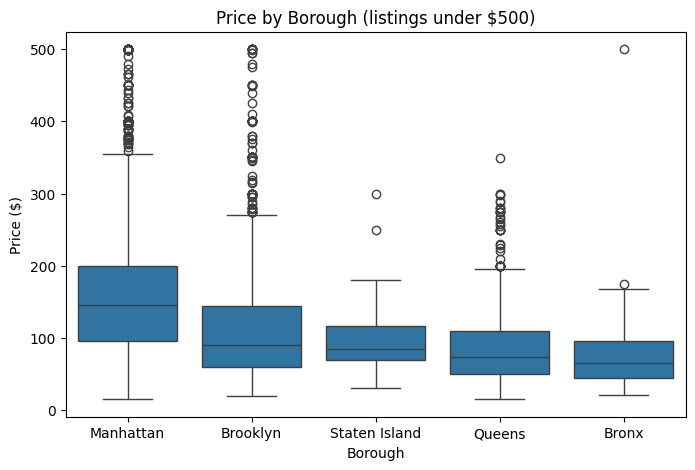

In [ ]:
plt.figure(figsize=(8, 5))
order = df_clean.groupby("neighbourhood_group")["price"].median().sort_values(ascending=False).index
sns.boxplot(x="neighbourhood_group", y="price", data=df_clean[df_clean["price"] <= 500], order=order)
plt.title("Price by Borough (listings under $500)")
plt.xlabel("Borough")
plt.ylabel("Price ($)")
plt.show()

**Interpretation:** Manhattan has both the highest median price and the widest spread, followed by Brooklyn. The Bronx and Queens are noticeably cheaper. This lines up with general NYC real-estate patterns — Manhattan commands a clear location premium over the outer boroughs.

### 4.2 Price by Room Type

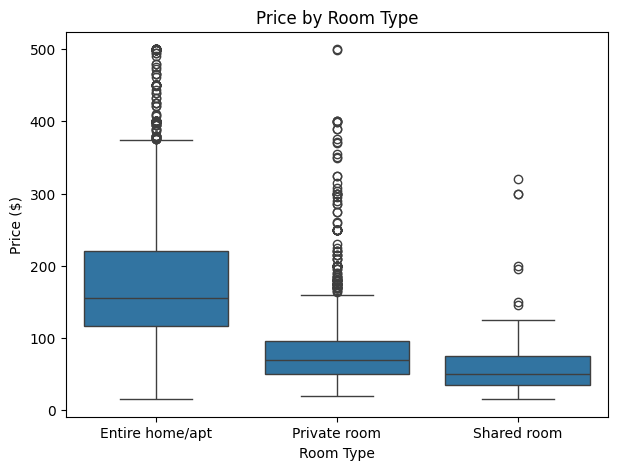

In [ ]:
plt.figure(figsize=(7, 5))
sns.boxplot(x="room_type", y="price", data=df_clean[df_clean["price"] <= 500],
            order=df_clean.groupby("room_type")["price"].median().sort_values(ascending=False).index)
plt.title("Price by Room Type")
plt.xlabel("Room Type")
plt.ylabel("Price ($)")
plt.show()

**Interpretation:** `Entire home/apt` is priced noticeably higher than `Private room`, which in turn is priced higher than `Shared room` — an intuitive ordering, since renting an entire space naturally costs more than sharing one. This variable looks like one of the strongest simple predictors of price.

### 4.3 Correlation Heatmap of Numeric Variables

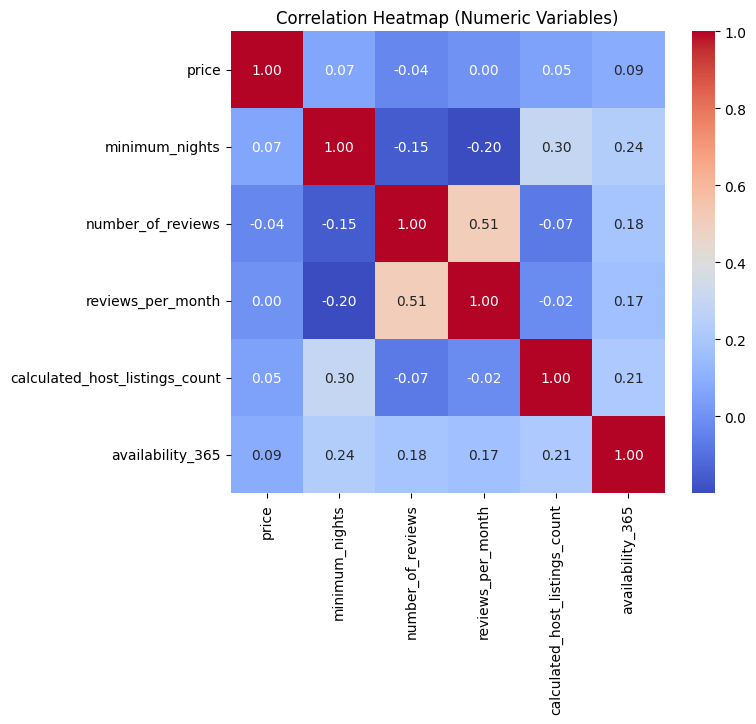

In [ ]:
corr_cols = ["price", "minimum_nights", "number_of_reviews", "reviews_per_month",
             "calculated_host_listings_count", "availability_365"]

plt.figure(figsize=(7, 6))
sns.heatmap(df_clean[corr_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap (Numeric Variables)")
plt.show()

**Interpretation:** None of the numeric variables correlate strongly with `price` — the strongest is `availability_365` (a weak positive relationship, roughly 0.09), meaning listings available more days per year tend to be *very slightly* more expensive. `number_of_reviews` and `reviews_per_month` are essentially uncorrelated with price. This tells us that price in this dataset is driven far more by **categorical** factors — location and room type — than by any of the numeric booking-activity variables.

### 4.4 Three-Variable Relationship: Price by Room Type, Within Each Borough

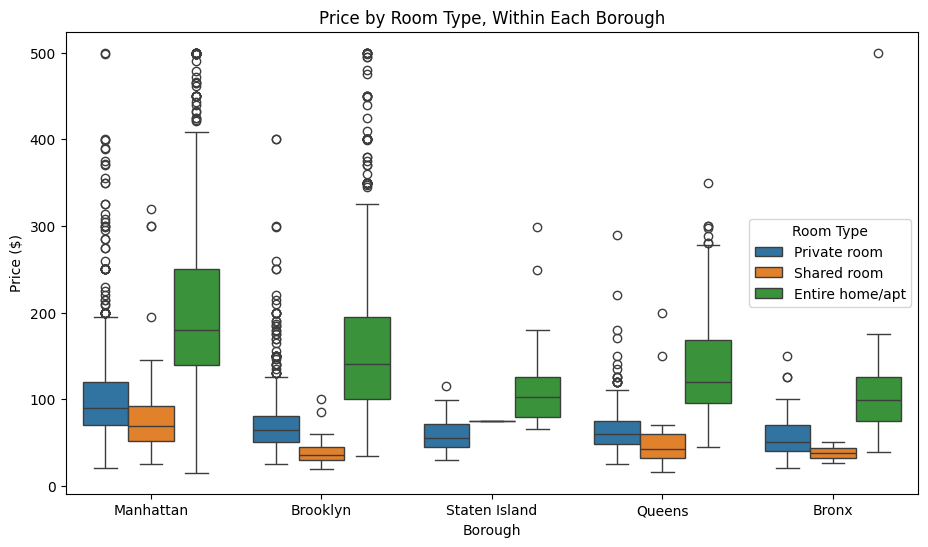

In [ ]:
plt.figure(figsize=(11, 6))
sns.boxplot(x="neighbourhood_group", y="price", hue="room_type",
            data=df_clean[df_clean["price"] <= 500],
            order=df_clean.groupby("neighbourhood_group")["price"].median().sort_values(ascending=False).index)
plt.title("Price by Room Type, Within Each Borough")
plt.xlabel("Borough")
plt.ylabel("Price ($)")
plt.legend(title="Room Type")
plt.show()

**Interpretation:** The room-type price gap holds up within every borough, but its *size* differs — in Manhattan, an entire home/apt commands a much bigger premium over a private room than it does in, say, the Bronx or Queens. This is a genuine interaction effect: location and room type don't just each add their own separate boost to price, they amplify each other, which neither the borough-only nor room-type-only chart showed on its own.

### 4.5 Price Category vs. Availability

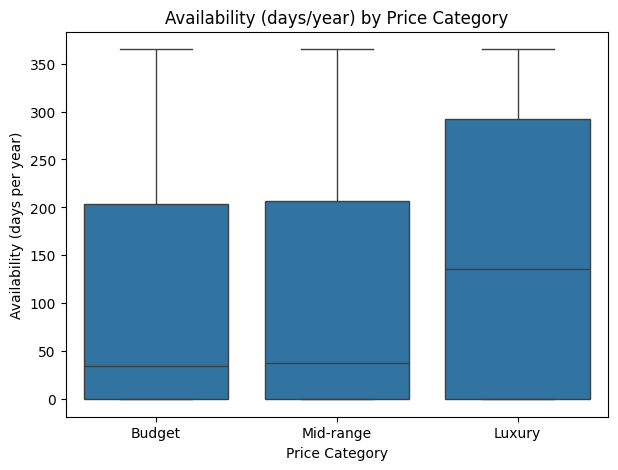

In [ ]:
plt.figure(figsize=(7, 5))
sns.boxplot(x="price_category", y="availability_365", data=df_clean,
            order=["Budget", "Mid-range", "Luxury"])
plt.title("Availability (days/year) by Price Category")
plt.xlabel("Price Category")
plt.ylabel("Availability (days per year)")
plt.show()

**Interpretation:** Luxury listings tend to be booked/blocked out less consistently and show a wider spread of availability than budget listings, hinting that higher-end listings may be run more casually (e.g., an occasionally-rented spare home) rather than as a full-time short-term rental business.

## 5. Summary of Key Insights

**Key findings from this EDA:**

1. **Location is the single biggest driver of price.** Manhattan listings are priced well above every other borough, with Brooklyn a clear second — this location premium mirrors NYC's real estate market generally.
2. **Room type is the second major driver.** Entire homes/apartments cost noticeably more than private rooms, which cost more than shared rooms, and this ordering holds in every borough.
3. **Location and room type interact.** The price premium for an entire home over a private room is much larger in Manhattan than in the outer boroughs — so the two factors compound rather than simply add.
4. **Booking-activity numbers barely relate to price.** `number_of_reviews`, `reviews_per_month`, and `minimum_nights` are all weakly or negligibly correlated with price, meaning review volume is not a proxy for how expensive a listing is.
5. **Missingness in reviews is meaningful, not random.** ~20% of listings have no reviews at all (matching gaps in `last_review` and `reviews_per_month`), representing genuinely new or rarely-booked listings rather than a data quality issue.
6. **Actionable recommendation:** A new host in the Bronx or Queens listing a private room should not expect Manhattan-level prices — but listing an *entire home* rather than a private room, even in a lower-priced borough, captures a meaningful price premium. If maximizing revenue is the goal, offering the entire space (where possible) matters more than location alone once you're outside Manhattan/Brooklyn.